# Импорты

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as scs
import pandas as pd

# Вариант 18

## Задание 1

Интервальный вариационный ряд:
                  Интервал  Частота $m_i$  Относительная частота $n_i$
              [1.88; 3.95)              9                         0.09
[3.95; 6.0200000000000005)             21                         0.21
[6.0200000000000005; 8.09)             26                         0.26
             [8.09; 10.16)             16                         0.16
            [10.16; 12.23)             12                         0.12
             [12.23; 14.3)              9                         0.09
             [14.3; 16.37]              7                         0.07


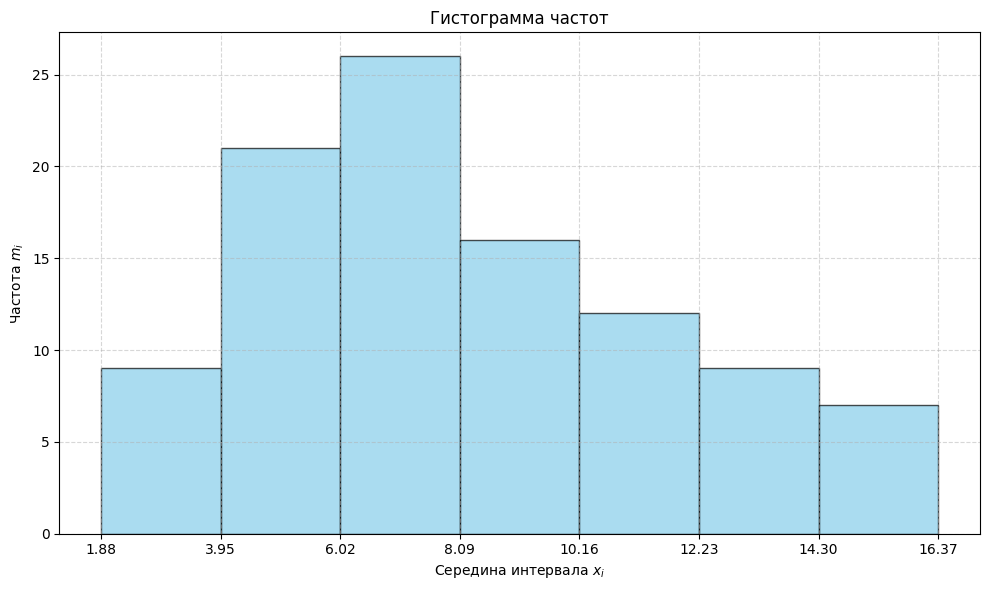

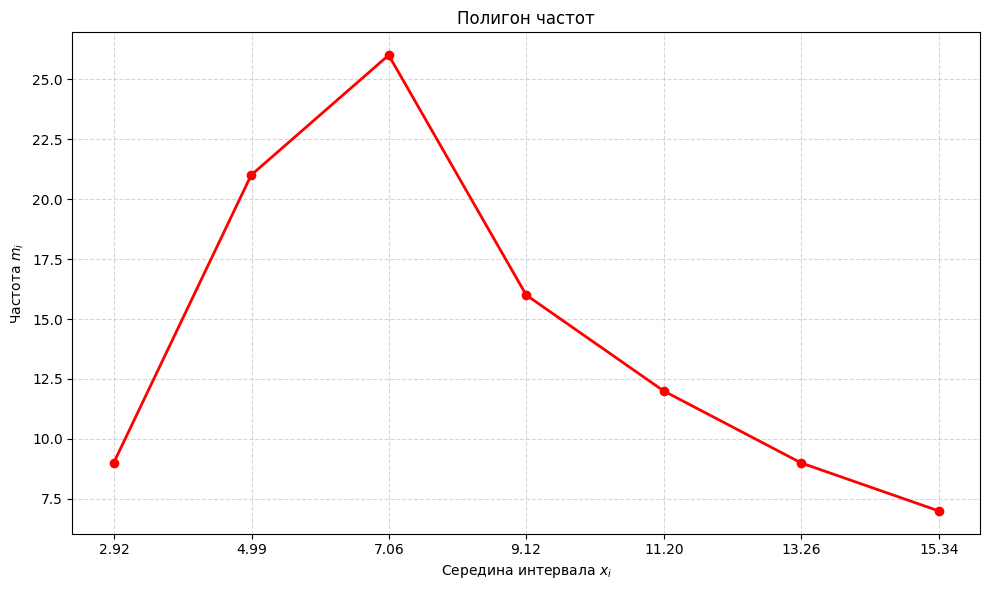

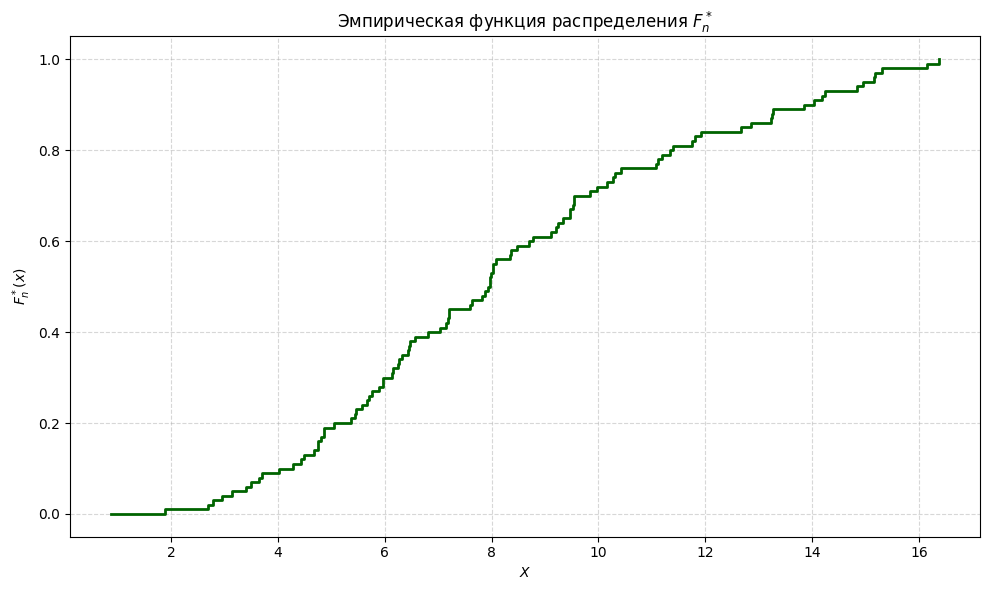

Среднее: 8.3139
Дисперсия: 12.288003789999998


In [2]:
X_N = [
    12.67,
    15.16,
    2.69,
    16.37,
    6.24,
    10.17,
    15.18,
    5.77,
    5.66,
    8.02,

    9.98,
    7.15,
    3.40,
    6.57,
    7.98,
    4.81,
    6.81,
    14.04,
    5.36,
    14.96,

    9.46,
    13.27,
    3.64,
    5.96,
    2.95,
    2.78,
    7.99,
    9.53,
    5.96,
    9.46,

    9.55,
    5.46,
    11.34,
    10.43,
    9.85,
    9.20,
    7.88,
    6.46,
    12.86,
    11.20,

    6.48,
    7.20,
    4.29,
    8.34,
    5.57,
    11.80,
    10.32,
    3.70,
    8.77,
    9.33,

    4.49,
    5.05,
    6.32,
    14.19,
    11.08,
    7.94,
    11.12,
    1.88,
    9.11,
    11.39,

    5.70,
    5.90,
    4.43,
    11.75,
    8.37,
    6.15,
    7.04,
    10.28,
    8.71,
    4.02,

    11.92,
    16.16,
    5.45,
    14.84,
    9.55,
    13.25,
    8.08,
    3.15,
    6.27,
    7.21,

    14.24,
    7.64,
    7.97,
    4.75,
    15.31,
    13.85,
    4.86,
    8.47,
    6.44,
    4.75,

    9.25,
    7.83,
    8.03,
    7.60,
    6.13,
    7.19,
    13.23,
    4.86,
    3.49,
    4.68
]

N = len(X_N)
k = int(1 + 3.322 * np.log10(N))
counts, bins = np.histogram(X_N, bins=k)

intervals = [f"[{bins[i]}; {bins[i+1]})" for i in range(k)]
intervals[-1] = intervals[-1][:-1] + "]"
interval_series = pd.DataFrame({
    r'Интервал': intervals,
    r'Частота $m_i$': counts,
    r'Относительная частота $n_i$': counts / N,
})
print("Интервальный вариационный ряд:")
print(interval_series.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.hist(X_N, bins=bins, edgecolor='black', alpha=0.7, color='skyblue', density=False)
plt.title('Гистограмма частот')
plt.xlabel(r'Середина интервала $x_i$')
plt.ylabel(r'Частота $m_i$')
plt.xticks(np.round(bins, 2))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

bin_centers = (bins[:-1] + bins[1:]) / 2
plt.figure(figsize=(10, 6))
plt.plot(bin_centers, counts, marker='o', linestyle='-', color='red', linewidth=2)
plt.title('Полигон частот')
plt.xlabel(r'Середина интервала $x_i$')
plt.ylabel(r'Частота $m_i$')
plt.xticks(np.round(bin_centers, 2))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

x_sorted = np.sort(X_N)
y_values = np.arange(1, N + 1) / N
x_ecdf = np.concatenate(([x_sorted[0] - 1], x_sorted))
y_ecdf = np.concatenate(([0], y_values))
plt.figure(figsize=(10, 6))
plt.step(x_ecdf, y_ecdf, where='post', color='darkgreen', linewidth=2)
plt.title(r'Эмпирическая функция распределения $F_n^*$')
plt.xlabel(r'$X$')
plt.ylabel(r'$F_n^*(x)$')
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

print(f"Среднее: {np.mean(X_N)}")
print(f"Дисперсия: {np.var(X_N)}")

## Задание 2

### Оценка параметров

$\displaystyle
X \sim U(a, b) \\
X_1, \ldots, X_n - \text{ выборка из } X \\
F_X \in \{F(x, a, b) ~|~ a, b \in \mathbb{R}, b \geq a\} \\
f_X(x) = \frac{I(x \in [a; b])}{(b - a)^n} \\
L(a, b, X_1, \ldots, X_n) = \prod_{i = 1}^n \frac{I(X_i \in [a; b])}{(b - a)^n} = \frac{1}{(b - a)^n} \prod_{i = 1}^n I(X_i \in [a; b]) \\
\^{a}_n = \argmax_{a \leq b} \frac{1}{(b - a)^n} \prod_{i = 1}^n I(X_i \in [a; b]) = \argmax_{a \leq X_{\min}} \frac{1}{(b - a)^n} = X_{\min} \\
\^{b}_n = \argmax_{b \geq a} \frac{1}{(b - a)^n} \prod_{i = 1}^n I(X_i \in [a; b]) = \argmax_{b \geq X_{\max}} \frac{1}{(b - a)^n} = X_{\max} \\
\text{Оценка параметра } \hat{a}_n = X_{\min} \\
\text{Оценка параметра } \hat{b}_n = X_{\max} \\
$

### Несмещённость

Оценка $\hat{\theta}_n$ является несмещённой, если $E(\hat{\theta}_n) = \theta$

$\displaystyle
P(X_{\min} > x) = P((X_1 > x) \cap \ldots \cap (X_n > x)) = P(X_1 > x) \cdot \ldots \cdot P(X_n > x) \\
1 - F_{X_{\min}}(x) = 1 - P(X_{\min} \leq x) = (1 - P(X_1 \leq x)) \cdot \ldots \cdot (1 - P(X_n \leq x)) = (1 - F_X(x))^n \\
F_{X_{\min}}(x) = 1 - (1 - F_X(x))^n \\
f_{X_{\min}}(x) = \frac{d F_{X_{\min}}}{dx} = n (1 - F_X(x))^{n - 1} f_X(x) = n \left( 1 - \frac{x - a}{b - a} \right)^{n - 1} \frac{1}{b - a} = \frac{n (b - x)^{n - 1}}{(b - a)^n} \\
E(X_{\min}) = \int_a^b \frac{x n (b - x)^{n - 1}}{(b - a)^n} dx = \frac{na + b}{n + 1} \\
F_{X_{\max}}(x) = P(X_{\max} \leq x) = P((X_1 \leq x) \cap \ldots \cap (X_n \leq x)) = P(X_1 \leq x) \cdot \ldots \cdot P(X_n \leq x) = F_X^n(x) \\
f_{X_{\max}}(x) = \frac{d F_{X_{\max}}}{dx} = n F_X^{n - 1}(x) f_X(x) = n \left( \frac{x - a}{b - a} \right)^{n - 1} \frac{1}{b - a} = \frac{n (x - a)^{n - 1}}{(b - a)^{n}} \\
E(X_{\max}) = \int_a^b \frac{x n (x - a)^{n - 1}}{(b - a)^{n}} dx = \frac{nb + a}{n + 1}
$

$
\left.\begin{array}{c}
    \displaystyle E(\hat{a}_n) = \frac{na + b}{n + 1} \neq a \\
    \displaystyle E(\hat{b}_n) = \frac{nb + a}{n + 1} \neq b
\end{array}\right\} \Rightarrow
$
Оценка смещённая

### Состоятельность

Оценка $\hat{\theta}_n$ является состоятельной, если $\displaystyle \hat{\theta}_n \xrightarrow{P} \theta \Leftrightarrow \forall \varepsilon > 0 \Rightarrow \lim_{n \rightarrow \infty} P(|\hat{\theta}_n - \theta| < \varepsilon) = 1$

$\displaystyle
\lim_{n \rightarrow \infty} P(|\hat{a}_n - a| < \varepsilon) = \lim_{n \rightarrow \infty} P(|X_{\min} - a| < \varepsilon) = \lim_{n \rightarrow \infty} P(X_{\min} - a < \varepsilon) \lim_{n \rightarrow \infty} P(X_{\min} < a + \varepsilon) = \lim_{n \rightarrow \infty} F_{X_{\min}}(a + \varepsilon) = \lim_{n \rightarrow \infty} \left( 1 - \left( \frac{b - a - \varepsilon}{b - a} \right)^n \right) = 1 \\
\lim_{n \rightarrow \infty} P(|\hat{b}_n - b| < \varepsilon) = \lim_{n \rightarrow \infty} P(|X_{\max} - b| < \varepsilon) = \lim_{n \rightarrow \infty} P(b - X_{\max} < \varepsilon) = \lim_{n \rightarrow \infty} P(X_{\max} > \varepsilon - b) = \lim_{n \rightarrow \infty} (1 - P(X_{\max} \leq b - \varepsilon)) = \lim_{n \rightarrow \infty} (1 - F_{X_{\max}}(b - \varepsilon)) = \lim_{n \rightarrow \infty} \left( 1 - \left( \frac{b - \varepsilon - a}{b - a} \right)^n \right) = 1
$

$
\left.\begin{array}{c}
    \displaystyle \hat{a}_n \xrightarrow{P} a \\
    \displaystyle \hat{b}_n \xrightarrow{P} b
\end{array}\right\} \Rightarrow
$
Оценка состоятельная

## Задание 3

In [3]:
X_N = [
    -3.39,
    -1.91,
    -19.90,
    14.53,
    10.55,
    -5.79,
    14.49,
    -3.35,
    1.05,

    -1.35,
    18.30,
    -7.19,
    12.93,
    -9.92,
    -5.56,
    15.47,
    -6.55,
    -8.78,
    
    0.71,
    10.74,
    8.13,
    1.93,
    1.28,
    -18.17,
    2.89,
    9.94,
    -7.21,

    13.70,
    -8.66,
    0.11,
    5.89,
    21.52,
    15.33,
    0.23,
    -1.02,
    -2.98
]

N = len(X_N)
k = N - 1
beta = 0.92
alpha = 1 - beta

X_mean = np.mean(X_N)
X_var = np.var(X_N)

print(f"Среднее: {X_mean}")
print(f"Дисперсия: {X_var}")
print(f"Среднеквадратичное отклонение: {np.sqrt(X_var)}")
print(f"Исправленная дисперсия: {X_var * N / (N - 1)}")
print(f"Исправленное среднеквадратичное отклонение: {np.sqrt(X_var * N / (N - 1))}")

print(f"t: {scs.t.ppf(1 - alpha / 2, k)}")
print(f"q: {max(1 - scs.chi.ppf((1 - beta) / 2, k) / (k ** 0.5), scs.chi.ppf((1 + beta) / 2, k) / (k ** 0.5) - 1)}")

Среднее: 1.888611111111111
Дисперсия: 99.64680084876544
Среднеквадратичное отклонение: 9.982324421133859
Исправленная дисперсия: 102.49385230158731
Исправленное среднеквадратичное отклонение: 10.12392474792199
t: 1.8030237267550329
q: 0.21050844541225444


Имеется выборка $X_1, \ldots, X_{36} \text{ из } X \sim N(\mu, \sigma^2)$

Доверительный интервал параметра $\mu$: <br>
$\displaystyle
\overline{X}_{B} - t \cdot \frac{S}{\sqrt{N}} < \mu < \overline{X}_{B} + t\frac{S}{\sqrt{N}} \\
1.89 - 1.8 \cdot \frac{10.12}{6} < \mu < 1.89 + 1.8 \cdot \frac{10.12}{6} \\
-1.15 < \mu < 4.93
$

Доверительный интервал параметра $\sigma$: <br>
$\displaystyle
S(1 - q) < \sigma < S(1 + q) \\
10.12 \cdot (1 - 0.21) < \sigma < 10.12 \cdot (1 + 0.21) \\
7.99 < \sigma < 12.25
$

# Задание 4

In [5]:
p = scs.chi2.cdf(105, df=100) - scs.chi2.cdf(95, df=100)
print(f"Вероятность: {p}")

Вероятность: 0.2760828884078516


$\displaystyle
n = 100 \\
\overline{D_0} = \frac{1}{n} \sum_{i = 1}^n (x_i - a)^2 \\
\text{Имеем } n \text{ случайных величин: } x_1, \ldots, x_{n} \sim N(a, \sigma^2) \\
\frac{x_i - a}{\sigma} \sim N(0, 1), ~~ i = \overline{1, n} \\
\sum_{i = 1}^{n} \left( \frac{x_i - a}{\sigma} \right)^2 = \frac{\overline{D_0} n}{\sigma^2} = X(n) \sim \chi^2(n) \\
P\left( \left| \frac{\overline{D_0} - \sigma^2}{\sigma^2} \right| \leq 0.05 \right) = P\left( -0.05 \leq \frac{\overline{D_0} - \sigma^2}{\sigma^2} \leq 0.05 \right) = P\left( -0.05 \leq \frac{\overline{D_0}}{\sigma^2} - 1 \leq 0.05 \right) = P\left( 0.95 \leq \frac{\overline{D_0}}{\sigma^2} \leq 1.05 \right) = P\left( 0.95n \leq \frac{\overline{D_0} n}{\sigma^2} \leq 1.05n \right) = P(95 \leq X(100) \leq 105) = F_{X(100)} (105) - F_{X(100)} (95) \approx 0.276
$